In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from natsort import natsorted
import pickle
import scipy
import matplotlib.animation as animation

plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

In [3]:
##############
### PARAMS ###
##############
s = 3/2
mub = 9.274e-24
mu0 = 4*np.pi*1e-7
a = 4e-10
h_planck = 6.626e-34

###############################
### SYSTEM DEPENDENT PARAMS ###
###############################
Lx = 833
Num = 59
mag = (np.sqrt(s/Lx) * (mu0 * (2*mub)**2)/(2 * a**3 *h_planck)) * 1e-3

sites = np.linspace(0,100,101)
xa = (sites*(np.sqrt(3)*Num/2 + 30)/100 - 15)*0.4

In [36]:
def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(b*x)

def linfit(x,a,b):
    return a*x + b

# MANR

## Wavefunctions

In [154]:
import math

def beta_sequence(num):
    """Return list [Beta[1],...,Beta[2*num]] matching the Mathematica RecurrenceTable."""
    step = math.sqrt(3) / 2
    return [((n - 1) // 2) * step for n in range(1, 2 * num + 1)]

# Example: Num = 3 -> returns Beta[1..6]
print(beta_sequence(3))  # [0.0, 0.0, 0.8660254037844386, 0.8660254037844386, 1.7320508075688772, 1.7320508075688772]

[0.0, 0.0, 0.8660254037844386, 0.8660254037844386, 1.7320508075688772, 1.7320508075688772]


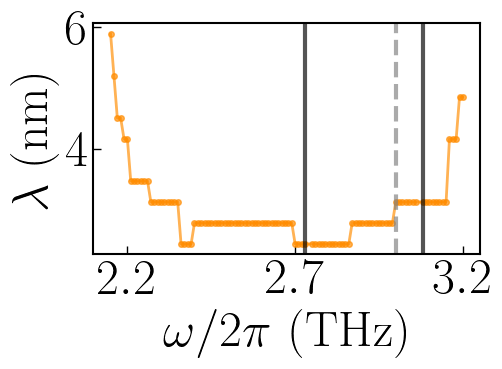

In [177]:
wfs = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\MANR_wf\MANR_wf_omega=*.bin"))
sites = np.linspace(1,118,118)
omega = np.linspace(2.15,3.2,106)
x = beta_sequence(Num)[::2]
idx = np.where((omega > 2.73) & (omega < 2.75) | (omega > 3.07) & (omega < 3.08))
omega = np.delete(omega, idx)
left_edge = []
right_edge = []
total = []
for wf in wfs:
    data = np.fromfile(wf)
    if np.sum(data[:59]) > np.sum(data[59:118]):
        left_edge.append(data[:118][::2])
        right_edge.append(data[118:236])
        total.append(data[:118] - data[118:236])
    else:
        left_edge.append(data[118:236][::2])
        right_edge.append(data[:118])
        total.append(data[118:236] - data[:118])

# plt.imshow(left_edge, aspect='auto', extent=(1,118,2.15,3.2), origin='lower',interpolation='gaussian',  vmin=1e-3, vmax=0.4)
lam = []
max_pos = []
edge_pos = []
for n in left_edge:
    # nint = scipy.interpolate.interp1d(sites[:len(sites)//2], n, kind='cubic')
    max_pos.append(x[np.where(n==np.max(n))[0][0]]*0.4)
    # edge_pos.append(nint(0))
    lam.append(x[(np.where(n<np.max(n)*0.001)[0][0])]*0.4)
    
plt.figure(figsize=(5,3))
plt.plot(omega,lam,marker='.',markersize=8,linestyle='-',linewidth=2,alpha=0.67,color='darkorange')
# plt.plot(omega,max_pos,marker='.',markersize=8,linestyle='-',linewidth=2,alpha=0.67,color='darkcyan')
plt.xlabel(r"$\omega/2\pi$ (THz)",fontsize=36)
plt.ylabel(r"$\lambda$ (nm)",fontsize=36)
plt.xticks([2.2,2.7,3.2])
plt.axvline(2.73, color='black', linestyle='-', linewidth=3,alpha=0.67)
plt.axvline(3.08, color='black', linestyle='-', linewidth=3,alpha=0.67)
plt.axvline(3.00, color='gray', linestyle='--', linewidth=3,alpha=0.67)
plt.tick_params(labelsize=36,direction="in",length=6,width=1,color='black')
plt.savefig("figures/x_vs_omega_lambda_V3.svg", dpi=300, bbox_inches='tight')

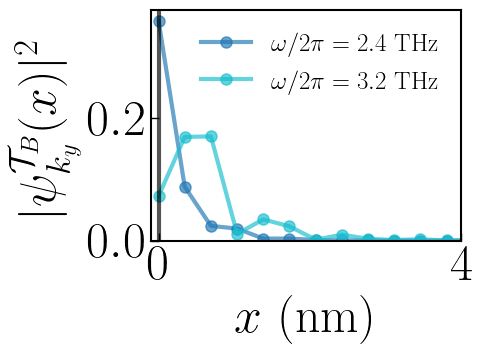

In [174]:
sites = np.linspace(1,59,59)
omegalist = np.array([2.40,3.2],dtype=object)
x = np.array(beta_sequence(Num)[::2])*0.4
colors = ['tab:blue', 'tab:cyan']
plt.figure(figsize=(4,3))
for omega in omegalist:
    left_edge = []
    data = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\MANR_wf\MANR_wf_omega={omega:.2f}.bin")
    if np.sum(data[:59]) > np.sum(data[59:118]):
        left_edge.append(data[:118][::2])
    else:
        left_edge.append(data[118:236][::2])
    plt.plot(x,data[:118][::2], marker='o',markersize=8,linestyle='-',linewidth=3,alpha=0.67,label=f"$\omega/2\pi={omega}$ THz", color=colors[omegalist.tolist().index(omega)])

plt.xlim(-0.1,4)
plt.ylim(0,)
plt.xticks([0,4])
plt.axvline(0, color='black', linestyle='-', linewidth=3,alpha=0.67)
plt.xlabel(r"$x$ (nm)",fontsize=36)
plt.ylabel(r"$|\psi_{k_y}^{\mathcal{T}_B}(x)|^2$",fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=6,width=1,color='black')
plt.legend(fontsize=18,frameon=False)
plt.savefig("figures/x_vs_omega_wavefunc_V3.svg", dpi=300, bbox_inches='tight')

## Profiles

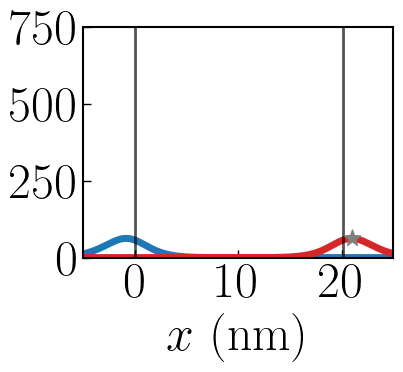

In [76]:
d=12.5
ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
# ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g_d=12.5_bin\MANR-SQ_g_d=15_omega=*.bin"))
left_edge = []
right_edge = []
cmap = plt.get_cmap("rainbow").resampled(len(ns[20:80][::2]))
plt.figure(figsize=(4,3))
for n in ns[20:100][::5]:
    # plt.figure(figsize=(8,4))
    nk = mag*np.fromfile(n, dtype=np.float64)
    x = np.linspace(min(xa), max(xa), 1000)
    if len(nk) != 202:
        # print(f"File {nk} has length {len(nk)}, expected 202. Skipping.")
        continue
    elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
        nk_int_left = scipy.interpolate.interp1d(xa, nk[:101], kind='cubic')
        nk_int_right = scipy.interpolate.interp1d(xa, nk[101:], kind='cubic')
        # plt.plot(x,nk_int_left(x),marker='',markersize=4,linewidth=3,color=cmap(ns[20:100][::5].index(n)))
        # plt.plot(x,nk_int_right(x),marker='',markersize=4,linewidth=3,color=cmap(ns[40:100][::5].index(n)))
    else:
        nk_int_left = scipy.interpolate.interp1d(xa, nk[101:], kind='cubic')
        nk_int_right = scipy.interpolate.interp1d(xa, nk[:101], kind='cubic')
        # plt.plot(x,nk_int_left(x),marker='',markersize=4,linewidth=3,color=cmap(ns[20:100][::5].index(n)))
        # plt.plot(x,nk_int_right(x),marker='',markersize=4,linewidth=3,color=cmap(ns[40:100][::5].index(n)))
    # plt.xlim(-5,5)
    # plt.ylim(0,400)

x = np.linspace(min(xa), max(xa), 1000)
nk = mag*np.fromfile(ns[4], dtype=np.float64)
nk_int_left = scipy.interpolate.interp1d(xa, nk[:101], kind='cubic')
nk_int_right = scipy.interpolate.interp1d(xa, nk[101:], kind='cubic')
plt.plot(x,nk_int_left(x),color='tab:blue',marker='',markersize=4,linewidth=5)
plt.plot(x,nk_int_right(x),color='tab:red',marker='',markersize=4,linewidth=5)
# plt.scatter(-0.48550608001683315, nk[16], color='black', s=100, marker='x')
plt.xlabel(r"$x$ (nm)",fontsize=36)
plt.ylabel(r"",fontsize=36)
plt.ylim(0,750)
# plt.yscale("log")
plt.xlim(-5,25)
plt.yticks([0,250,500,750], fontsize=42)
plt.xticks([0,10,20], fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=6,width=1,color='black')
plt.axvline(x=0, color='black', linewidth=2, linestyle='-', alpha=0.67)
plt.axvline(x=np.sqrt(3)*(Num-1)*0.4/2, color='black', linewidth=2, linestyle='-', alpha=0.67)

maxg_right = max(nk_int_right(x))
maxg_idx = np.where(nk_int_right(x) == maxg_right)[0][0]
maxg_x = x[maxg_idx]
plt.scatter(maxg_x, maxg_right, color='gray', s=150, marker='*', zorder=5)


# plt.savefig(f"figures/d={d}_MANR_edge_modes.svg", dpi=300, bbox_inches='tight')

## Density Plots

d=5 max omega: 2.26
d=12.5 max omega: 2.17
d=25 max omega: 2.1399999999999997


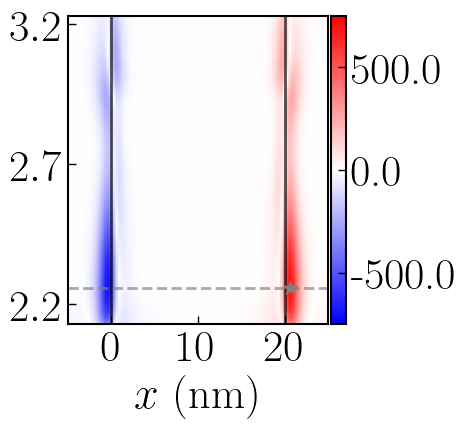

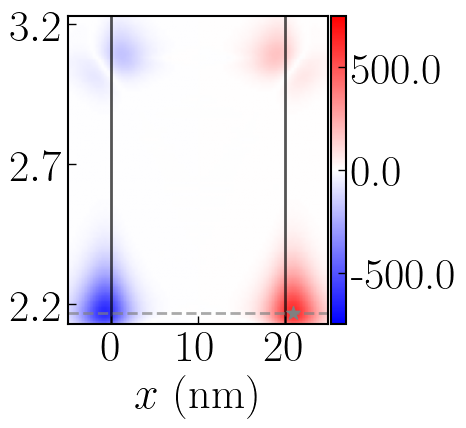

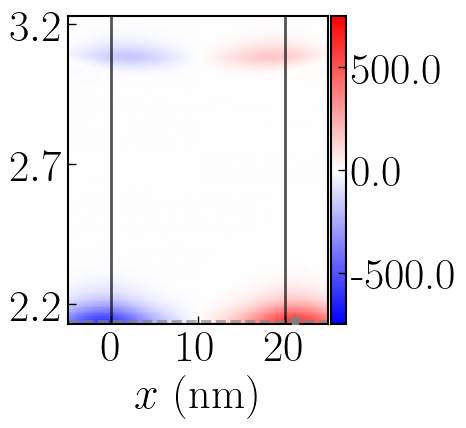

In [ ]:
# dlist = np.array([5, 7.5, 10, 12.5, 15, 17.5, 20, 22.5, 25],dtype=object)
dlist = np.array([5, 12.5, 25],dtype=object)
magnification = [1, 10, 50]
   
for d in dlist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    # ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g_d=12.5_bin\MANR-SQ_g_d=15_omega=*.bin"))
    omegalist = np.linspace(2.13,3.24,112)
    left_edge = []
    right_edge = []
    total = []
    for n in ns:
        nk = mag*np.fromfile(n)*magnification[np.where(dlist==d)[0][0]]
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            left_edge.append(nk[:101])
            right_edge.append(nk[101:])
            total.append(nk[101:]-nk[:101])
        else:
            left_edge.append(nk[101:])
            right_edge.append(nk[:101])
            total.append(nk[:101]-nk[101:])

    plt.figure(figsize=(4,4))
    # plt.imshow(left_edge, aspect='auto', interpolation="gaussian", norm='linear', extent=[min(xa),max(xa),2.15,3.2], origin='lower',  alpha=0.5, cmap='Reds')
    # plt.imshow(right_edge, aspect='auto', interpolation="gaussian", norm='linear', extent=[min(xa),max(xa),2.15,3.2], origin='lower', alpha=0.5, cmap='Blues')
    im = plt.imshow(total, aspect='auto',  norm='linear', extent=[min(xa),max(xa),2.13,3.23], origin='lower', alpha=1.0, cmap='bwr',vmax=750,vmin=-750)
    plt.xlabel(r"$x$ (nm)",fontsize=32)
    # plt.ylabel(r"$\omega/2\pi$ (THz)",fontsize=40)
    plt.yticks([2.2,2.7,3.2], fontsize=32) #,["", "", "", "", "", ""]
    plt.xticks([0,10,20], fontsize=32)
    plt.tick_params(labelsize=32,direction="in",length=6,width=1,color='black')
    cb = plt.colorbar(format='%.1f',pad=0.01,location='right')
    im.figure.axes[1].tick_params(axis='both',labelsize=32,direction="in",length=6,width=1,color='black')
    plt.axvline(x=0, color='black', linewidth=2, linestyle='-', alpha=0.67)
    plt.axvline(x=np.sqrt(3)*(Num-1)*0.4/2, color='black', linewidth=2, linestyle='-', alpha=0.67)
    # plt.show()

    # idx = [np.where(left_edge[j] == np.max(left_edge[j]))[0][0] for j in range(len(left_edge))]
    # max_pos = []
    # for j in idx:
    #     max_pos.append(xa[j])
 
    # omegas = np.linspace(2.15,3.2,len(left_edge))
    # plt.plot(max_pos, omegas, marker='', linestyle='--', color='white')

    plt.xlim(-5,25)
    max_pos = np.where(total  == np.max(total))
    maxomega = max_pos[0][0]
    print(f"d={d} max omega: {omegalist[maxomega]}")
    max_x = xa[max_pos[1][0]]
    plt.axhline(y=omegalist[maxomega], color='gray', linewidth=2, linestyle='--', alpha=0.67)
    # plt.axvline(x=max_x, color='gray', linewidth=2, linestyle='--', alpha=0.67)
    plt.scatter(max_x, omegalist[maxomega], color='gray', s=100, marker='*', zorder=5)
    plt.savefig(f"figures/d={d}_MANR_edge_modes_heatmap_V2.svg", dpi=300, bbox_inches='tight')
# plt.scatter(-0.48550608001683315, 2.25, color='white', s=100, marker='x')
# plt.savefig("figures/d=25_MANR_edge_modes_heatmap.svg", dpi=300, bbox_inches='tight')

## Scaling

### With $\omega$

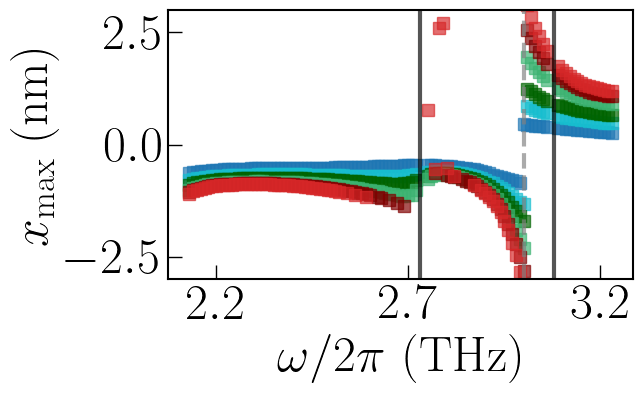

In [ ]:
dlist = np.array([5, 7.5, 10, 15, 20, 25],dtype=object)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
colors = ['tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']

omegalist = np.linspace(2.13,3.23,111,dtype=object)
idx = np.where((omegalist > 2.72) & (omegalist < 2.75) | (omegalist > 3.06) & (omegalist < 3.09))
omegalist = np.delete(omegalist, idx)   
x = np.linspace(-5, 5, 10000)
right = np.sqrt(3)*(Num-1)*0.4/2
cmap = plt.get_cmap("cool").resampled(len(omegalist))

plt.figure(figsize=(6,3.5))

for d in dlist:
    maxposition = []  # Reset maxposition for each omega
    for omega in omegalist:
        nk = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega={omega:_.2f}_V2.bin")
        if len(nk) != 202:
            # print(f"File {nk} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:25]) > np.sum(nk[75:101]):
            nk_int_left = scipy.interpolate.interp1d(xa[:50], nk[:101][:50], kind='cubic')
        else:
            nk_int_left = scipy.interpolate.interp1d(xa[:50], nk[101:][:50], kind='cubic')
        max_pos = np.where(nk_int_left(x) == np.max(nk_int_left(x)))[0][0]
        maxposition.append(x[max_pos])
    plt.plot(omegalist, np.array(maxposition), marker='s', linestyle='',markersize=8, linewidth=2, alpha=0.67, color=colors[np.where(dlist==d)[0][0]], label=rf"$\omega/2\pi={omega}$ (THz)")

plt.ylabel(r"$x_{\max}$ (nm)",fontsize=36)
plt.xlabel(r"$\omega/2\pi$ (THz)",fontsize=36)
plt.xticks([2.2,2.7,3.2], fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
plt.axvline(x=2.73, color='black', linestyle='-', linewidth=3,alpha=0.67)
plt.axvline(x=3.08, color='black', linestyle='-', linewidth=3,alpha=0.67)
plt.axvline(x=3.00, color='gray', linestyle='--', linewidth=3,alpha=0.67)
# plt.xlim(2.9,3.2)
plt.ylim(-3,3)
# plt.yscale("log")
# plt.legend(frameon=False, fontsize=14, ncols=2)

# ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist_all.bin", dtype=np.float64)
# ax2 = plt.twiny()
# plt.tick_params(labelsize=32,direction="in",length=10,width=1,color='black')
# ax2.set_xticks(np.linspace(0,1,len(ks[::20])),np.round(ks[::20],2))
# ax2.set_xlabel(r"$|k_y|a$", fontsize=36)

plt.savefig("figures/xmax_v_omega.svg", dpi=300, bbox_inches='tight')

####  $\max g$

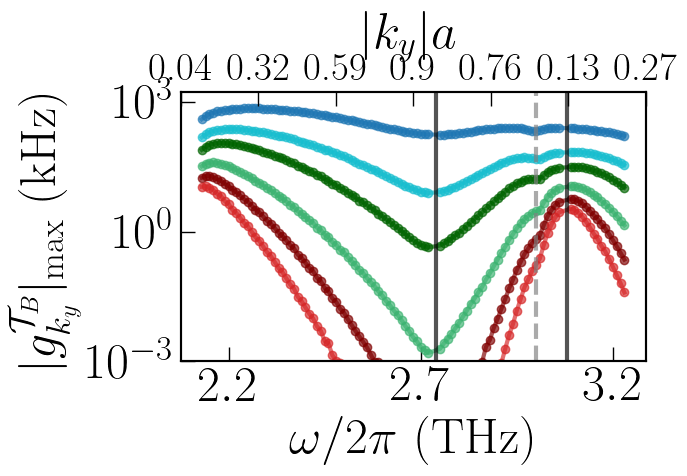

In [86]:
dlist = np.array([5,7.5,10,15,20,25],dtype=object)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
colors = ['tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']



def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(b*x)

plt.figure(figsize=(6,3.5))
for d in dlist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            left_edge.append(nk[:101])
            # right_edge.append(nk[101:])
        else:
            left_edge.append(nk[101:])
            # right_edge.append(nk[:101])


    maxg = np.max(left_edge,axis=1)
    omega = np.linspace(2.13,3.23,111)
    idx = np.where((omega > 2.72) & (omega < 2.75) | (omega > 3.06) & (omega < 3.09))
    omega = np.delete(omega, idx)
    plt.plot(omega, maxg, label=rf"$d={d}a$",marker='o',linewidth=3,alpha=0.67,linestyle='-',color=colors[np.where(dlist==d)[0][0]])
    plt.xticks([2.2,2.7,3.2], fontsize=24)
    # popt, pcov = scipy.optimize.curve_fit(fit_func, omega[:50], maxg[:50],maxfev = 8000, bounds=([0, -np.inf, -np.inf], [np.inf, 0, np.inf]))
    # plt.plot(omega, fit_func(omega, *popt), linestyle='-',color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
plt.ylabel(r"$|g_{k_y}^{\mathcal{T}_B}|_{\max}$ (kHz)",fontsize=36)
plt.xlabel(r"$\omega/2\pi$ (THz)",fontsize=36)
plt.yscale("log")
# plt.xscale("log")
plt.axvline(x=2.74,color='black', linestyle='-', alpha=0.67,linewidth=3)
plt.axvline(x=3.08,color='black', linestyle='-', alpha=0.67,linewidth=3)
plt.axvline(x=3,color='gray', linestyle='--', alpha=0.67,linewidth=3)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
# plt.xlim(2.75)
plt.ylim(1e-3,)
# plt.legend(frameon=False, fontsize=36, ncols=3, bbox_to_anchor=(1.05, 1))

ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist_all.bin", dtype=np.float64)
ax2 = plt.twiny()
plt.tick_params(labelsize=28,direction="in",length=10,width=1,color='black')
ax2.set_xticks(np.linspace(0,1,len(ks[::18])),np.round(ks[::18],2))
ax2.set_xlabel(r"$|k_y|a$", fontsize=36)

plt.savefig("figures/omega_vs_maxg_V2.svg", dpi=300, bbox_inches='tight')

####  $g(x=0)$

Text(0.5, 0, '$|k_y|a$')

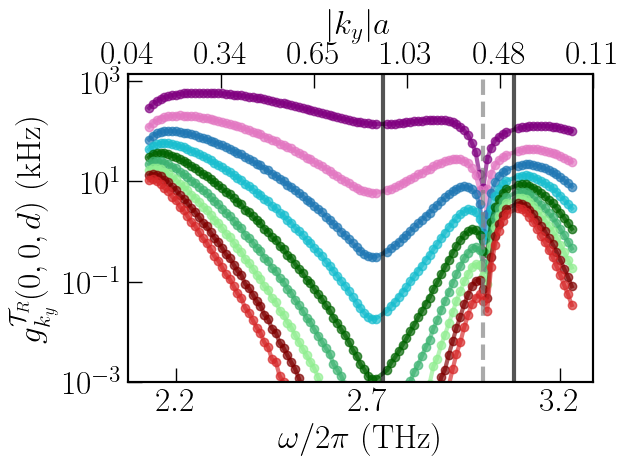

In [16]:
dlist = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25],dtype=object)
colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
edge = np.argmin(np.abs(xa))
# edge=10

plt.figure(figsize=(6,4))
for d in dlist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    g_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            g_edge.append(nk[:101][edge])
        else:
            g_edge.append(nk[101:][edge])


    omega = np.linspace(2.13,3.23,111)
    idx = np.where((omega > 2.72) & (omega < 2.75) | (omega > 3.06) & (omega < 3.09))
    omega = np.delete(omega, idx)
    plt.plot(omega, g_edge, label=rf"$d={d}a$",marker='o',linewidth=3,alpha=0.67,linestyle='-',color=colors[np.where(dlist==d)[0][0]])
    plt.xticks([2.2,2.7,3.2], fontsize=24)
    # popt, pcov = scipy.optimize.curve_fit(fit_func, omega[:50], maxg[:50],maxfev = 8000, bounds=([0, -np.inf, -np.inf], [np.inf, 0, np.inf]))
    # plt.plot(omega, fit_func(omega, *popt), linestyle='-',color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
plt.ylabel(r"$g_{k_y}^{\mathcal{T}_R}(0,0,d)$ (kHz)",fontsize=24)
plt.xlabel(r"$\omega/2\pi$ (THz)",fontsize=24)
plt.yscale("log")
# plt.xscale("log")
plt.axvline(x=2.74,color='black', linestyle='-', alpha=0.67,linewidth=3)
plt.axvline(x=3.08,color='black', linestyle='-', alpha=0.67,linewidth=3)
plt.axvline(x=3,color='gray', linestyle='--', alpha=0.67,linewidth=3)
plt.tick_params(labelsize=24,direction="in",length=10,width=1,color='black')
# plt.xlim(2.75)
plt.ylim(1e-3,)
# plt.legend(frameon=False, fontsize=18, ncols=2)

ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist_all.bin", dtype=np.float64)
ax2 = plt.twiny()
plt.tick_params(labelsize=24,direction="in",length=10,width=1,color='black')
ax2.set_xticks(np.linspace(0,1,len(ks[::20])),np.round(ks[::20],2))
ax2.set_xlabel(r"$|k_y|a$", fontsize=24)

# plt.savefig("figures/omega_vs_maxg_V2.svg", dpi=300, bbox_inches='tight')

### with $k_y$

d=5a: a=6.09e+03 ± 7.67e+01, b=4.13e+00 ± 3.22e-02, c=1.00 ± 0.00
d=7.5a: a=3.06e+03 ± 2.70e+01, b=6.26e+00 ± 3.18e-02, c=1.00 ± 0.00
d=10a: a=1.88e+03 ± 1.69e+01, b=8.13e+00 ± 4.08e-02, c=1.00 ± 0.00
d=12.5a: a=1.31e+03 ± 1.21e+01, b=1.00e+01 ± 5.10e-02, c=1.00 ± 0.00
d=15a: a=9.83e+02 ± 9.87e+00, b=1.19e+01 ± 6.46e-02, c=1.00 ± 0.00
d=17.5a: a=7.78e+02 ± 8.59e+00, b=1.38e+01 ± 8.13e-02, c=1.00 ± 0.00
d=20a: a=6.39e+02 ± 7.74e+00, b=1.57e+01 ± 1.00e-01, c=1.00 ± 0.00
d=22.5a: a=5.39e+02 ± 7.09e+00, b=1.77e+01 ± 1.21e-01, c=1.00 ± 0.00
d=25a: a=4.65e+02 ± 6.54e+00, b=1.96e+01 ± 1.42e-01, c=1.00 ± 0.00


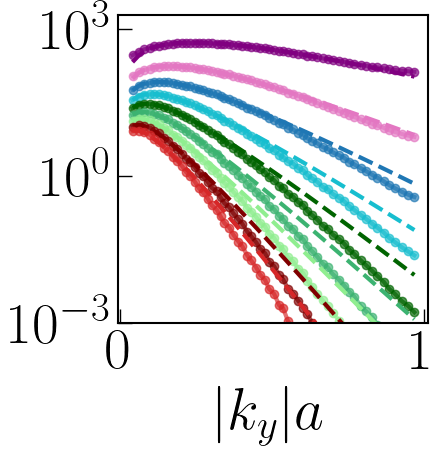

In [333]:
klist = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist.bin", dtype=np.float64)
dlist = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25],dtype=object)
colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
# dlist = np.array([5,7.5,10,15,20,25],dtype=object)
# colors = ['tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']

def fit_func(x,a,b,c):
    return a*(x**1)*np.exp(-b*x)

# def fit_func(x,a,b):
#     return a*(x)*np.exp(b*x)

b = []
b_err = []
c = []
c_err = []

plt.figure(figsize=(4,4))
for d in dlist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            left_edge.append(nk[:101])
        else:
            left_edge.append(nk[101:])


    maxg = np.max(left_edge,axis=1)
    omega = np.linspace(2.13,3.23,111)
    plt.plot(klist, maxg[:len(klist)], label=rf"$d={d}a$",marker='o',linewidth=3,alpha=0.67,linestyle='-',color=colors[np.where(dlist==d)[0][0]])
    # popt, pcov = scipy.optimize.curve_fit(fit_func, klist, maxg[:len(klist)],maxfev = 8000, bounds=([0, -np.inf], [np.inf, 0]))
    popt, pcov = scipy.optimize.curve_fit(fit_func, klist, maxg[:len(klist)],maxfev = 8000, bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))
    plt.plot(klist, fit_func(klist, *popt), linestyle='--',linewidth=3,color=colors[np.where(dlist==d)[0][0]])
    err = np.sqrt(np.diag(pcov))
    b.append(popt[1])
    b_err.append(err[1])
    c.append(popt[2])
    c_err.append(err[2])
    print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}, c={popt[2]:.2f} ± {err[2]:.2f}")
    # print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}")
# plt.ylabel(r"$\max g_{k_y}^{\mathcal{T}_R}(\mathbf{r}_{SQ})$ (kHz)",fontsize=36)
plt.xlabel(r"$|k_y|a$",fontsize=42)
plt.yscale("log")
# plt.xscale("log")
plt.tick_params(labelsize=42,direction="in",length=10,width=1,color='black')
# plt.xlim(0,np.pi/3)
# plt.xscale("log")
plt.ylim(1e-3,2*1e3)
# plt.legend(frameon=False, fontsize=18, ncols=2)
plt.savefig("figures/ky_vs_maxg_V3.svg", dpi=300, bbox_inches='tight')

Fit parameters: a=0.95 ± 0.01, b=-1.14 ± 0.07


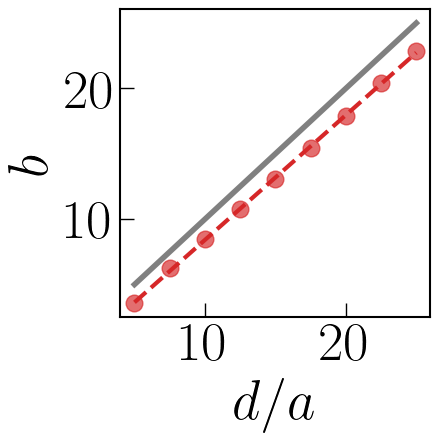

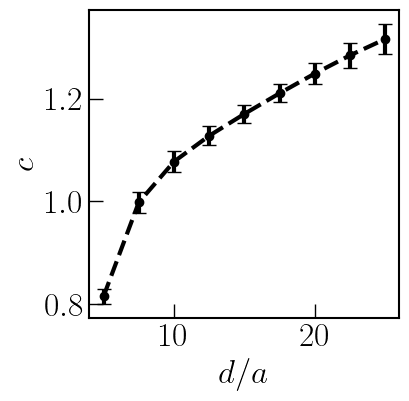

In [97]:
def linfit(x,a,b):
    return a*x + b

d = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
b = np.array(b)
with open("pickles/b_regI.pkl", "wb") as f:
    pickle.dump(b, f)
c = np.array(c)
plt.figure(figsize=(4,4))
# plt.errorbar(d,np.abs(b), yerr=b_err, marker='o',linewidth=3, linestyle='', color='tab:red', capsize=5, alpha=0.67)
plt.plot(d,b, marker='o',markersize=12, linestyle='', color='tab:red',  alpha=0.67)
plt.plot(d,d, marker='', linestyle='-',color='gray',linewidth=4)
popt, pcov = scipy.optimize.curve_fit(linfit, d, np.abs(b), sigma=np.abs(b_err), absolute_sigma=True)
plt.plot(d, linfit(d, *popt), linestyle='--',linewidth=3, color='tab:red', alpha=1)
print(f"Fit parameters: a={popt[0]:.2f} ± {np.sqrt(pcov[0][0]):.2f}, b={popt[1]:.2f} ± {np.sqrt(pcov[1][1]):.2f}")


plt.xlabel(r"$d/a$",fontsize=40)
plt.ylabel(r"$b$",fontsize=40)
plt.tick_params(labelsize=40,direction="in",length=10,width=1,color='black')
plt.savefig("figures/d_vs_b_V2.svg", dpi=300, bbox_inches='tight')
# plt.yscale("log")
# plt.ylim(1e-3,1e3)

d = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
c = np.array(c)
plt.figure(figsize=(4,4))
plt.errorbar(d,c, yerr=np.abs(c_err), marker='o', linestyle='--',linewidth=3, color='black', capsize=5)
# plt.plot(d,d, marker='o', linestyle='--', color='tab:red')
plt.xlabel(r"$d/a$",fontsize=24)
plt.ylabel(r"$c$",fontsize=24)
plt.tick_params(labelsize=24,direction="in",length=10,width=1,color='black')


In [99]:
klist = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist2.bin", dtype=np.float64)
dlist = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25],dtype=object)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
# dlist = np.array([5,7.5,10,15,20,25],dtype=object)
# colors = ['tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']
omega = np.linspace(2.13,3.23,111)


def fit_func2(x,a,b,c,d):
    x = x-d
    return a*(x**c)*np.exp(-b*x)
    
def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(-b*x)

b = []
b_err = []
c = []
c2_err = []
b2 = []
b2_err = []
c2 = []
c2_err = []

plt.figure(figsize=(4,4))
for d in dlist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            left_edge.append(nk[:101])
        else:
            left_edge.append(nk[101:])


    maxg = np.max(left_edge,axis=1)
    maxg = maxg[np.where(omega==2.75)[0][0]:np.where(omega==3.07)[0][0]]
    # plt.plot(klist, maxg, label=rf"$d={d}a$",marker='o',alpha=0.67,linestyle='',color=colors[np.where(dlist==d)[0][0]])
    popt,pcov = scipy.optimize.curve_fit(fit_func, klist[:-8], maxg[:-8],maxfev = 8000, bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
    b.append(popt[1])
    b_err.append(np.sqrt(pcov[1][1]))
    c.append(popt[2])
    c_err.append(np.sqrt(pcov[1][2]))
    # plt.plot(np.flip(klist), fit_func(np.flip(klist), *popt), linestyle='-',linewidth=3,color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
    popt2,pcov2 = scipy.optimize.curve_fit(fit_func, klist[-8:], maxg[-8:],maxfev = 8000, bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
    # plt.plot(np.flip(klist), fit_func(np.flip(klist), *popt2), linestyle='--',linewidth=3,color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
    b2.append(popt2[1])
    b2_err.append(np.sqrt(pcov2[1][1]))
    c2.append(popt2[2])
    c2_err.append(np.sqrt(pcov2[1][2]))
    
    # popt, pcov = scipy.optimize.curve_fit(fit_func, klist, maxg[:len(klist)],maxfev = 8000, bounds=([0, -np.inf], [np.inf, 0]))
    # popt, pcov = scipy.optimize.curve_fit(fit_func, np.flip(klist)[:8], maxg[np.where(omega==2.75)[0][0]:np.where(omega==3.07)[0][0]][-8:],maxfev = 8000, bounds=([0, -np.inf, -np.inf, 0], [np.inf, 0, np.inf, 1]))
    # popt2, pcov2 = scipy.optimize.curve_fit(fit_func, np.flip(klist)[8:], maxg[np.where(omega==2.75)[0][0]:np.where(omega==3.07)[0][0]][8:],maxfev = 8000, bounds=([0, -np.inf, -np.inf,0], [np.inf, 0, np.inf, 1]))
    # plt.plot(klist, fit_func(klist, *popt), linestyle='--',color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
    # plt.plot(np.flip(klist), fit_func(klist, *popt2), linestyle='-.',color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
    # err = np.sqrt(np.diag(pcov))
    # b.append(popt[1])
    # b_err.append(err[1])
    # c.append(popt[2])
    # c_err.append(err[2])
    # print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}, c={popt[2]:.2f} ± {err[2]:.2f}")
    # print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}")
# plt.ylabel(r"",fontsize=42)
# plt.xlabel(r"",fontsize=42)
# plt.yscale("log")
# # plt.xscale("log")
# plt.tick_params(labelsize=42,direction="in",length=10,width=1,color='black')
# # plt.xlim(2.14,2.65)
# plt.ylim(1e-3,2*1e3)
# # plt.legend(frameon=False, fontsize=18, ncols=2)

# plt.savefig("figures/ky_vs_maxg_V3_reg2.svg", dpi=300, bbox_inches='tight')

def linfit(x,a,b):
    return a*x + b

d = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
b = np.array(b)
b2 = np.array(b2)
with open("pickles/b1_regII.pkl", "wb") as f:
    pickle.dump(b, f)
with open("pickles/b2_regII.pkl", "wb") as f:
    pickle.dump(b2, f)
# c = np.array(c)
# c2 = np.array(c2)
# plt.figure(figsize=(4,4))
# plt.errorbar(d,b, yerr=b_err, marker='o',linewidth=3, markersize=12,linestyle='', color='tab:red', capsize=5, alpha=0.67)
# popt, pcov = scipy.optimize.curve_fit(linfit, d, np.abs(b), sigma=np.abs(b_err), absolute_sigma=True)
# plt.errorbar(d,b2, yerr=b2_err, marker='s',linewidth=3, markersize=12, linestyle='', color='tab:blue', capsize=5, alpha=0.67)
# popt2, pcov2 = scipy.optimize.curve_fit(linfit, d, np.abs(b2), sigma=np.abs(b2_err), absolute_sigma=True)
# plt.plot(d,d, marker='', linestyle='-',color='gray',linewidth=2)
# plt.plot(d, linfit(d, *popt), linestyle='--',linewidth=3, color='tab:red', alpha=1)
# plt.plot(d, linfit(d, *popt2), linestyle='--',linewidth=3, color='tab:blue', alpha=1)
# print(f"Fit parameters: a={popt[0]:.2f} ± {np.sqrt(pcov[0][0]):.2f}, b={popt[1]:.2f} ± {np.sqrt(pcov[1][1]):.2f}")
# print(f"Fit parameters: a={popt2[0]:.2f} ± {np.sqrt(pcov2[0][0]):.2f}, b={popt2[1]:.2f} ± {np.sqrt(pcov2[1][1]):.2f}")


# plt.xlabel(r"$d/a$",fontsize=40)
# plt.ylabel(r"$b$",fontsize=40)
# plt.tick_params(labelsize=40,direction="in",length=10,width=1,color='black')
# # plt.yscale("log")
# # plt.ylim(1e-3,1e3)
# plt.savefig("figures/b_vs_d_fit_V2_reg2.svg", dpi=300, bbox_inches='tight')

# # d = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
# # plt.figure(figsize=(4,4))
# # plt.errorbar(d,c, yerr=np.abs(c_err), marker='o', linestyle='--',linewidth=3, color='tab:red', capsize=5)
# # plt.errorbar(d,c2, yerr=np.abs(c2_err), marker='o', linestyle='--',linewidth=3, color='tab:blue', capsize=5)
# # # plt.plot(d,d, marker='o', linestyle='--', color='tab:red')
# # plt.xlabel(r"$d/a$",fontsize=24)
# # plt.ylabel(r"$c$",fontsize=24)

<Figure size 400x400 with 0 Axes>

In [100]:
ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist_all.bin", dtype=np.float64)
omega = np.linspace(2.13,3.23,111)
idx = np.where(omega > 3.08)[0][0]
ks = ks[idx:]
dlist = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25],dtype=object)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
# dlist = np.array([5,7.5,10,15,20,25],dtype=object)
# colors = ['tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']

b=[]
b_err = []
c = []
c_err = []  


def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(-b*x)


plt.figure(figsize=(4,4))
for d in dlist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            left_edge.append(nk[:101])
        else:
            left_edge.append(nk[101:])


    maxg = np.max(left_edge,axis=1)
    # plt.plot(ks, maxg[:len(ks)], label=rf"$d={d}a$",marker='o',alpha=0.67,linestyle='',color=colors[np.where(dlist==d)[0][0]])
    # plt.plot(ks, maxg[:len(ks)], label=rf"$d={d}a$",marker='o',linewidth=3,alpha=0.67,linestyle='-',color=colors[np.where(dlist==d)[0][0]])
    # popt, pcov = scipy.optimize.curve_fit(fit_func, klist, maxg[:len(klist)],maxfev = 8000, bounds=([0, -np.inf], [np.inf, 0]))
    popt, pcov = scipy.optimize.curve_fit(fit_func, ks, maxg[:len(ks)],maxfev = 8000, bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))
    # plt.plot(ks, fit_func(ks, *popt), linestyle='--',linewidth=3,color=colors[np.where(dlist==d)[0][0]])
    err = np.sqrt(np.diag(pcov))
    b.append(popt[1])
    b_err.append(err[1])
    c.append(popt[2])
    c_err.append(err[2])
    print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}, c={popt[2]:.2f} ± {err[2]:.2f}")
    # print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}")
# plt.ylabel(r"",fontsize=36)
# plt.xlabel(r"",fontsize=36)
# plt.yscale("log")
# # plt.xscale("log")
# plt.tick_params(labelsize=42,direction="in",length=10,width=1,color='black')
# # plt.xlim(2.14,2.65)
# plt.ylim(1e-3,2*1e3)
# # plt.legend(frameon=False, fontsize=18, ncols=2)
# plt.savefig("figures/ky_vs_maxg_fit_V3_reg3.svg", dpi=300, bbox_inches='tight')

# def linfit(x,a,b):
#     return a*x + b

# d = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
b = np.array(b)
with open("pickles/b_regIII.pkl", "wb") as f:
    pickle.dump(b, f)
# c = np.array(c)
# plt.figure(figsize=(4,4))
# plt.errorbar(d,np.abs(b), yerr=b_err, marker='o',markersize=12,linewidth=3, linestyle='', color='tab:red', capsize=5, alpha=0.67)
# plt.plot(d,d/2, marker='', linestyle='-',color='gray',linewidth=2)
# popt, pcov = scipy.optimize.curve_fit(linfit, d, np.abs(b), sigma=np.abs(b_err), absolute_sigma=True)
# plt.plot(d, linfit(d, *popt), linestyle='--',linewidth=3, color='tab:red', alpha=1)
# print(f"Fit parameters: a={popt[0]:.2f} ± {np.sqrt(pcov[0][0]):.2f}, b={popt[1]:.2f} ± {np.sqrt(pcov[1][1]):.2f}")


# plt.xlabel(r"$d/a$",fontsize=40)
# plt.ylabel(r"$b$",fontsize=40)
# plt.tick_params(labelsize=40,direction="in",length=10,width=1,color='black')
# # plt.yscale("log")
# # plt.ylim(1e-3,1e3)
# plt.savefig("figures/b_vs_d_fit_V2_reg3.svg", dpi=300, bbox_inches='tight')

# d = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
# c = np.array(c)
# plt.figure(figsize=(4,4))
# plt.errorbar(d,c, yerr=np.abs(c_err), marker='o', linestyle='--',linewidth=3, color='black', capsize=5)
# # plt.plot(d,d, marker='o', linestyle='--', color='tab:red')
# plt.xlabel(r"$d/a$",fontsize=24)
# plt.ylabel(r"$c$",fontsize=24)

d=5a: a=1.64e+03 ± 7.63e+01, b=1.21e+00 ± 1.05e-01, c=0.40 ± 0.02
d=7.5a: a=8.60e+02 ± 4.69e+01, b=2.72e+00 ± 1.26e-01, c=0.48 ± 0.02
d=10a: a=6.05e+02 ± 3.57e+01, b=4.39e+00 ± 1.40e-01, c=0.56 ± 0.02
d=12.5a: a=4.61e+02 ± 2.90e+01, b=6.10e+00 ± 1.56e-01, c=0.60 ± 0.02
d=15a: a=3.63e+02 ± 2.57e+01, b=7.83e+00 ± 1.85e-01, c=0.63 ± 0.02
d=17.5a: a=2.93e+02 ± 2.38e+01, b=9.57e+00 ± 2.25e-01, c=0.64 ± 0.02
d=20a: a=2.41e+02 ± 2.30e+01, b=1.13e+01 ± 2.79e-01, c=0.65 ± 0.03
d=22.5a: a=2.02e+02 ± 2.27e+01, b=1.31e+01 ± 3.50e-01, c=0.66 ± 0.03
d=25a: a=1.72e+02 ± 2.27e+01, b=1.50e+01 ± 4.36e-01, c=0.66 ± 0.04


<Figure size 400x400 with 0 Axes>

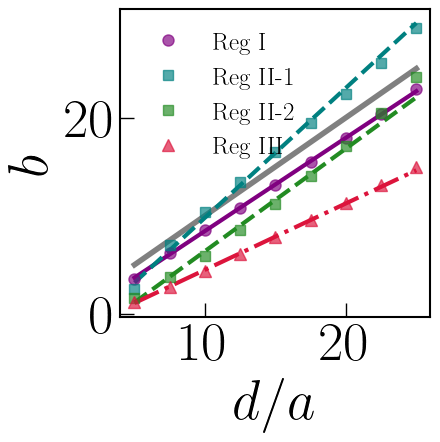

In [118]:
with open("pickles/b_regI.pkl", "rb") as f:
    b_regI = pickle.load(f)
with open("pickles/b1_regII.pkl", "rb") as f:
    b1_regII = pickle.load(f)
with open("pickles/b2_regII.pkl", "rb") as f:
    b2_regII = pickle.load(f)
with open("pickles/b_regIII.pkl", "rb") as f:
    b_regIII = pickle.load(f)
    
dlist = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25],dtype=object)
colors = ['purple','teal','forestgreen','crimson']

plt.figure(figsize=(4,4))
plt.plot(dlist, dlist, marker='', linestyle='-',color='gray',linewidth=4)
plt.errorbar(dlist, b_regI, yerr=None, marker='o', markersize=8, linestyle='', color=colors[0], label='Reg I',alpha=0.67)
popt,pcov = scipy.optimize.curve_fit(linfit, dlist, np.abs(b_regI), sigma=np.abs(b_err), absolute_sigma=True)
plt.plot(dlist, linfit(dlist, *popt), linestyle='-',linewidth=3, color=colors[0], alpha=1)

plt.errorbar(dlist, b1_regII, yerr=None, marker='s', markersize=7, linestyle='', color=colors[1], label='Reg II-1',alpha=0.67)
popt,pcov = scipy.optimize.curve_fit(linfit, dlist, np.abs(b1_regII), sigma=np.abs(b_err), absolute_sigma=True)
plt.plot(dlist, linfit(dlist, *popt), linestyle='--',linewidth=3, color=colors[1], alpha=1)

plt.errorbar(dlist, b2_regII, yerr=None, marker='s', markersize=7, linestyle='', color=colors[2], label='Reg II-2',alpha=0.67)
popt,pcov = scipy.optimize.curve_fit(linfit, dlist, np.abs(b2_regII), sigma=np.abs(b_err), absolute_sigma=True)
plt.plot(dlist, linfit(dlist, *popt), linestyle='--',linewidth=3, color=colors[2], alpha=1)

plt.errorbar(dlist, b_regIII, yerr=None, marker='^', markersize=8, linestyle='', color=colors[3], label='Reg III',alpha=0.67)
popt,pcov = scipy.optimize.curve_fit(linfit, dlist, np.abs(b_regIII), sigma=np.abs(b_err), absolute_sigma=True)
plt.plot(dlist, linfit(dlist, *popt), linestyle='-.',linewidth=3, color=colors[3], alpha=1)

plt.xlabel(r"$d/a$",fontsize=40)
plt.ylabel(r"$b$",fontsize=40)
plt.tick_params(labelsize=40,direction="in",length=10,width=1,color='black')
plt.legend(frameon=False, fontsize=18, ncols=1)
plt.savefig("figures/b_vs_d_all_regs.svg", dpi=300, bbox_inches='tight')

d=5a: a=3.16e+02 ± 1.11e+02, b=2.59e-13 ± 4.38e-01, c=-0.11 ± 0.14
d=7.5a: a=5.38e+01 ± 2.61e+01, b=6.84e-16 ± 6.59e-01, c=-0.34 ± 0.18


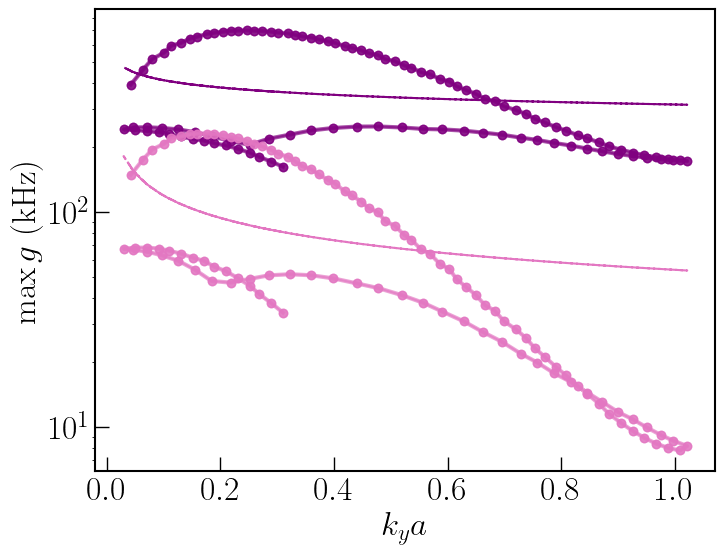

In [89]:
klist = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist_all.bin", dtype=np.float64)
omega = np.linspace(2.13,3.23,111)
idx = np.where((omega > 2.72) & (omega < 2.75) | (omega > 3.06) & (omega < 3.09))
klist = np.delete(klist, idx)
dlist = np.array([5,7.5,10,12.5,15,17.5,20,22.5,25],dtype=object)
colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']


def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(b*x)

# def fit_func(x,a,b):
#     return a*(x)*np.exp(b*x)

b = []
b_err = []
c = []
c_err = []

plt.figure(figsize=(8,6))
for d in dlist[:2]:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega=*_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if len(nk) != 202:
            # print(f"File {n} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            left_edge.append(nk[:101])
            right_edge.append(nk[101:])
        else:
            left_edge.append(nk[101:])
            right_edge.append(nk[:101])


    maxg = np.max(left_edge,axis=1)
    plt.plot(klist, maxg[:len(klist)], label=rf"$d={d}a$",marker='o',linewidth=3,alpha=0.67,linestyle='-',color=colors[np.where(dlist==d)[0][0]])
    # popt, pcov = scipy.optimize.curve_fit(fit_func, klist, maxg[:len(klist)],maxfev = 8000, bounds=([0, -np.inf], [np.inf, 0]))
    popt, pcov = scipy.optimize.curve_fit(fit_func, klist, maxg[:len(klist)],maxfev = 8000, bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))
    plt.plot(klist, fit_func(klist, *popt), linestyle='--',color=colors[np.where(dlist==d)[0][0]])
    err = np.sqrt(np.diag(pcov))
    b.append(popt[1])
    b_err.append(err[1])
    c.append(popt[2])
    c_err.append(err[2])
    plt.plot(klist, maxg, label=rf"$d={d}a$",marker='o',alpha=0.67,linestyle='-',color=colors[np.where(dlist==d)[0][0]])
    print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}, c={popt[2]:.2f} ± {err[2]:.2f}")
    # print(f"d={d}a: a={popt[0]:.2e} ± {err[0]:.2e}, b={popt[1]:.2e} ± {err[1]:.2e}")
plt.ylabel(r"$\max g$ (kHz)",fontsize=24)
plt.xlabel(r"$k_ya$",fontsize=24)
plt.yscale("log")
# plt.xscale("log")
plt.tick_params(labelsize=24,direction="in",length=10,width=1,color='black')
# plt.xlim(2.14,2.65)
# plt.ylim(1e-3,1e3)
# plt.legend(frameon=False, fontsize=18, ncols=2)

### with $d$

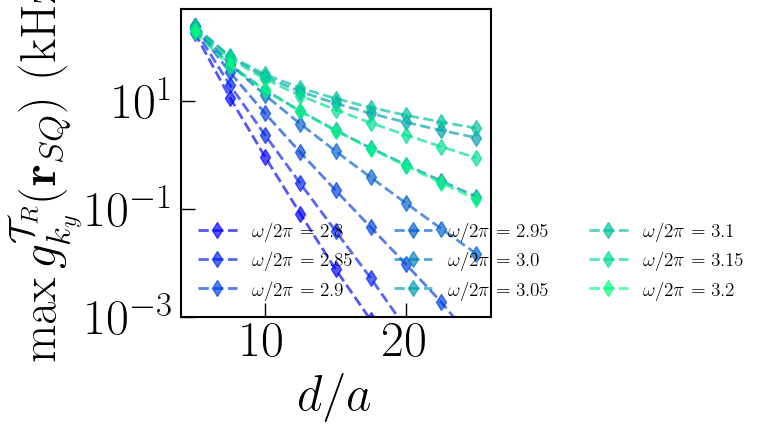

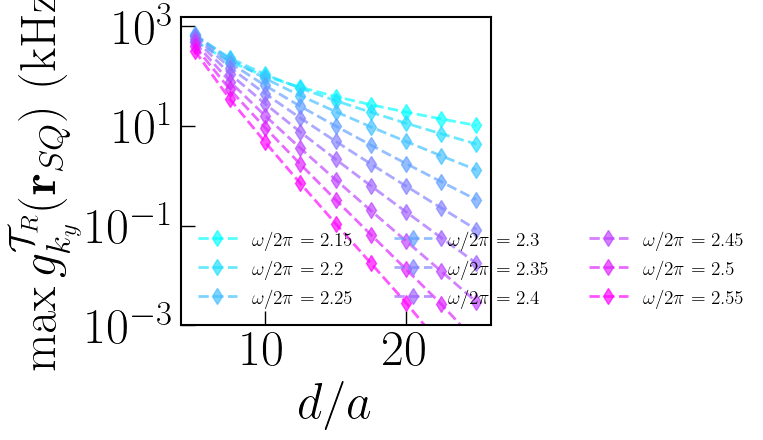

In [4]:
omegalist = np.array([2.8,2.85,2.90,2.95,3.0,3.05,3.10,3.15,3.20],dtype=object)
colors = ['purple','tab:pink','tab:blue','cyan','darkgreen','mediumseagreen', 'lightgreen','tab:red','maroon']
d =  np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
cmap = plt.get_cmap("winter").resampled(len(d))

def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(b*x)

plt.figure(figsize=(4,4))
for omega in omegalist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d=*_omega={omega:.2f}_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if nk[0] > nk[101]:
            left_edge.append(nk[:101])
        else:
            left_edge.append(nk[101:])


    maxg = np.max(left_edge,axis=1)
    plt.plot(d, maxg, label=rf"$\omega/2\pi={omega}$",marker='d',markersize=8,linestyle='--',linewidth=2,alpha=0.67,color=cmap(np.where(omegalist==omega)[0][0]))
plt.ylabel(r"$\max g_{k_y}^{\mathcal{T}_R}(\mathbf{r}_{SQ})$ (kHz)",fontsize=36)
plt.xlabel(r"$d/a$",fontsize=36)
plt.yscale("log")
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
# plt.xlim(4.85,10.5)
plt.ylim(1e-3)
plt.legend(frameon=False, fontsize=14, ncols=3)
plt.savefig("figures/d_vs_maxg_omegadep_V2_high.svg", dpi=300, bbox_inches='tight')

omegalist = np.array([2.15,2.20,2.25,2.30,2.35,2.40,2.45,2.50,2.55], dtype=np.float64)
colors = ['purple','tab:pink','tab:blue','cyan','darkgreen','mediumseagreen', 'lightgreen','tab:red','maroon']
d =  np.array([5,7.5,10,12.5,15,17.5,20,22.5,25])
cmap = plt.get_cmap("cool").resampled(len(d))

def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(b*x)

plt.figure(figsize=(4,4))
for omega in omegalist:
    ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d=*_omega={omega:.2f}_V2.bin"))
    left_edge = []
    for n in ns:
        nk = mag*np.fromfile(n)
        if nk[0] > nk[101]:
            left_edge.append(nk[:101])
        else:
            left_edge.append(nk[101:])


    maxg = np.max(left_edge,axis=1)
    plt.plot(d, maxg, label=rf"$\omega/2\pi={omega}$",marker='d',markersize=8,linestyle='--',linewidth=2,alpha=0.67,color=cmap(np.where(omegalist==omega)[0][0]))
plt.ylabel(r"$\max g_{k_y}^{\mathcal{T}_R}(\mathbf{r}_{SQ})$ (kHz)",fontsize=36)
plt.xlabel(r"$d/a$",fontsize=36)
plt.yscale("log")
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
# plt.xlim(4.85,10.5)
plt.ylim(1e-3)

plt.legend(frameon=False, fontsize=14, ncols=3)

plt.savefig("figures/d_vs_maxg_omegadep_V2_low.svg", dpi=300, bbox_inches='tight')

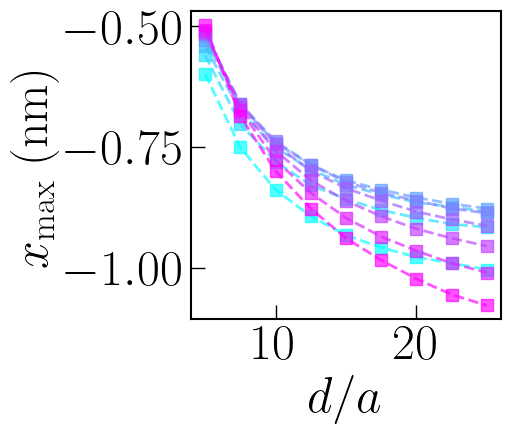

In [174]:
dlist = np.array([5, 7.5, 10, 12.5, 15, 17.5, 20, 22.5, 25],dtype=object)
omegalist = np.array([2.15,2.20,2.25,2.30,2.35,2.40,2.45,2.50,2.54],dtype=object)
x = np.linspace(min(xa), max(xa), 10000)
right = np.sqrt(3)*(Num-1)*0.4/2
cmap = plt.get_cmap("cool").resampled(len(omegalist))

plt.figure(figsize=(4,4))

for omega in omegalist:
    maxposition = []  # Reset maxposition for each omega
    for d in dlist:
        nk = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega={omega:_.2f}_V2.bin")
        if len(nk) != 202:
            print(f"File {nk} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            nk_int_left = scipy.interpolate.interp1d(xa, nk[:101], kind='cubic')
        else:
            nk_int_left = scipy.interpolate.interp1d(xa, nk[101:], kind='cubic')
        max_pos = np.where(nk_int_left(x) == np.max(nk_int_left(x)))[0][0]
        maxposition.append(x[max_pos])
        
    plt.plot(dlist, np.array(maxposition), marker='s', linestyle='--',markersize=8, linewidth=2, alpha=0.67, color=cmap(np.where(omegalist==omega)[0][0]), label=rf"$\omega/2\pi={omega}$ (THz)")

plt.ylabel(r"$x_{\max}$ (nm)",fontsize=36)
plt.xlabel(r"$d/a$",fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
# plt.legend(frameon=False, fontsize=14, ncols=2)
plt.savefig("figures/d_vs_xmax_omegadep_V2_low.svg", dpi=300, bbox_inches='tight')

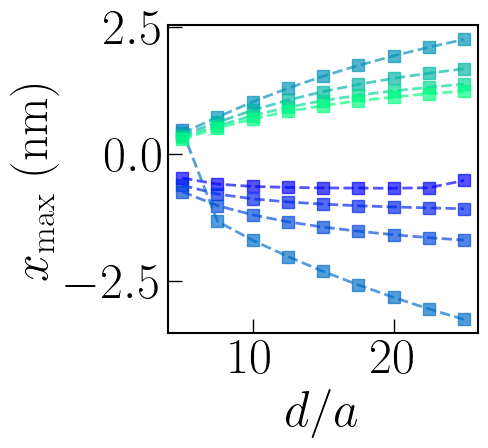

In [175]:
dlist = np.array([5, 7.5, 10, 12.5, 15, 17.5, 20, 22.5, 25],dtype=object)
omegalist = np.array([2.8,2.90,2.95,3.0,3.05,3.10,3.15,3.20],dtype=object)
x = np.linspace(min(xa), max(xa), 10000)
right = np.sqrt(3)*(Num-1)*0.4/2
cmap = plt.get_cmap("winter").resampled(len(omegalist))

plt.figure(figsize=(4,4))

for omega in omegalist:
    maxposition = []  # Reset maxposition for each omega
    for d in dlist:
        nk = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g\MANR-SQ_g_d={d}_omega={omega:_.2f}_V2.bin")
        if len(nk) != 202:
            print(f"File {nk} has length {len(nk)}, expected 202. Skipping.")
            continue
        elif np.sum(nk[0:50]) > np.sum(nk[50:101]):
            nk_int_left = scipy.interpolate.interp1d(xa, nk[:101], kind='cubic')
        else:
            nk_int_left = scipy.interpolate.interp1d(xa, nk[101:], kind='cubic')
        max_pos = np.where(nk_int_left(x) == np.max(nk_int_left(x)))[0][0]
        maxposition.append(x[max_pos])
        
    plt.plot(dlist, np.array(maxposition), marker='s', linestyle='--',markersize=8, linewidth=2, alpha=0.67, color=cmap(np.where(omegalist==omega)[0][0]), label=rf"$\omega/2\pi={omega}$ (THz)")

plt.ylabel(r"$x_{\max}$ (nm)",fontsize=36)
plt.xlabel(r"$d/a$",fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
# plt.legend(frameon=False, fontsize=14, ncols=2)
plt.savefig("figures/d_vs_xmax_omegadep_V2_high.svg", dpi=300, bbox_inches='tight')
    

# Zigzag

## Density Plots

d=5 max omega: 3.17
d=12.5 max omega: 3.23


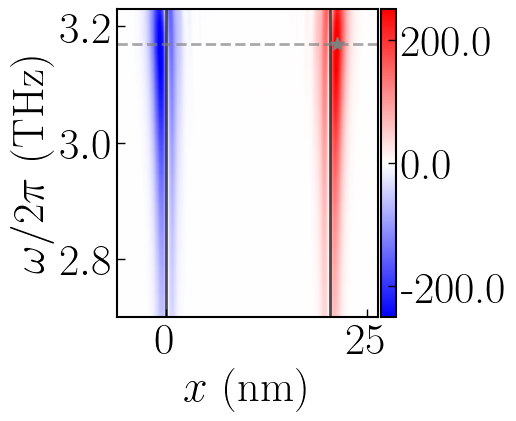

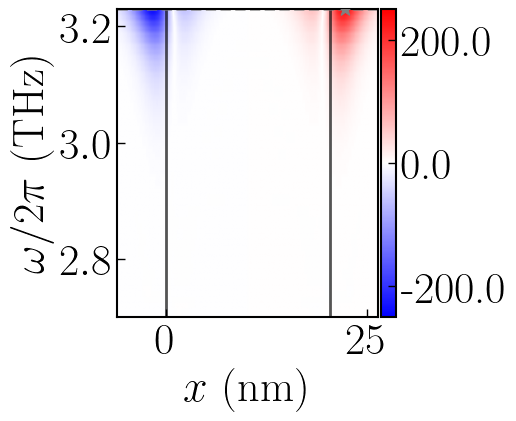

In [43]:
Num=34
sites = np.linspace(0,204,205)
xa = (sites*(3*Num/2 + 30)/204 - 15)*0.4
mag = (np.sqrt(s/1444) * (mu0 * (2*mub)**2)/(2 * a**3 *h_planck)) * 1e-3
# dlist = np.array([5, 6.25, 7.5, 8.75, 10,11.25,12.5],dtype=object)
dlist = np.array([5, 12.5],dtype=object)
magnifications = [1,30]
omegalist = np.linspace(2.7,3.23,54,dtype=object)
   
for d in dlist:  
    left_edge = []
    right_edge = []
    total = []
    for omega in omegalist:
        nk = mag*np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin")*magnifications[np.where(d == dlist)[0][0]]
        if len(nk) != 410:
            print(f"File for d={d}, omega={omega} has length {len(nk)}, expected 410. Skipping.")
            continue
        if np.sum(nk[0:100]) > np.sum(nk[250:350]):
            left_edge.append(nk[:205])
            right_edge.append(nk[205:])
            total.append(nk[205:]-nk[:205])
        else:
            left_edge.append(nk[205:])
            right_edge.append(nk[:205])
            total.append(nk[:205]-nk[205:])

    plt.figure(figsize=(4,4))
    im = plt.imshow(total, aspect='auto',  norm='linear', extent=[min(xa),max(xa),min(omegalist),max(omegalist)], origin='lower', alpha=1.0, cmap='bwr',vmax=250,vmin=-250) #,vmax=750,vmin=-750
    plt.xlabel(r"$x$ (nm)",fontsize=32)
    plt.ylabel(r"$\omega/2\pi$ (THz)",fontsize=32)
    # plt.yticks([2.2,2.7,3.2], fontsize=32) #,["", "", "", "", "", ""]
    # plt.xticks([0,10,20], fontsize=32)
    plt.tick_params(labelsize=32,direction="in",length=6,width=1,color='black')
    cb = plt.colorbar(format='%.1f',pad=0.01,location='right')
    im.figure.axes[1].tick_params(axis='both',labelsize=32,direction="in",length=6,width=1,color='black')
    plt.axvline(x=0, color='black', linewidth=2, linestyle='-', alpha=0.67)
    plt.axvline(x=3*(Num)*0.4/2, color='black', linewidth=2, linestyle='-', alpha=0.67)

    # plt.xlim(-5,25)
    max_pos = np.where(total  == np.max(total))
    maxomega = max_pos[0][0]
    print(f"d={d} max omega: {omegalist[maxomega]}")
    max_x = xa[max_pos[1][0]]
    plt.axhline(y=omegalist[maxomega], color='gray', linewidth=2, linestyle='--', alpha=0.67)
    plt.scatter(max_x, omegalist[maxomega], color='gray', s=100, marker='*', zorder=5)

## 3D Plots

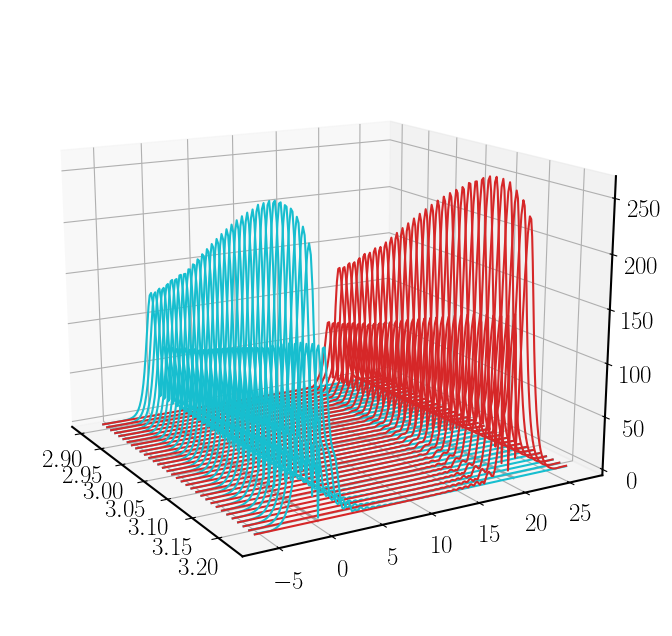

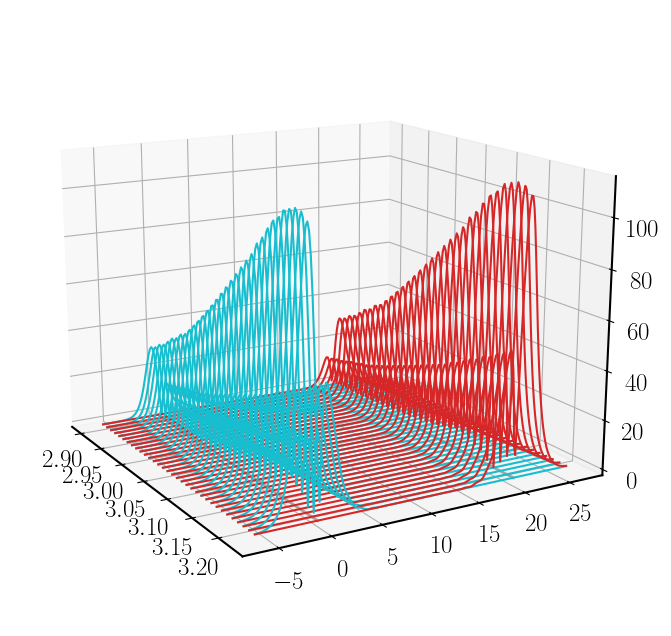

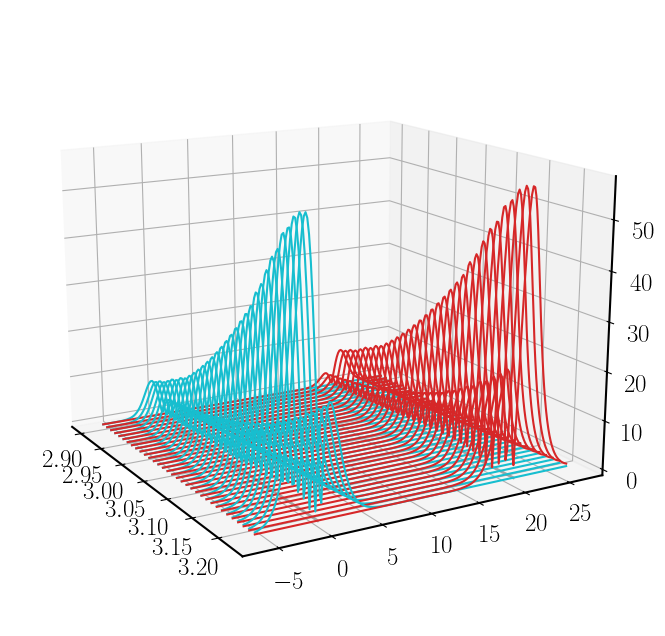

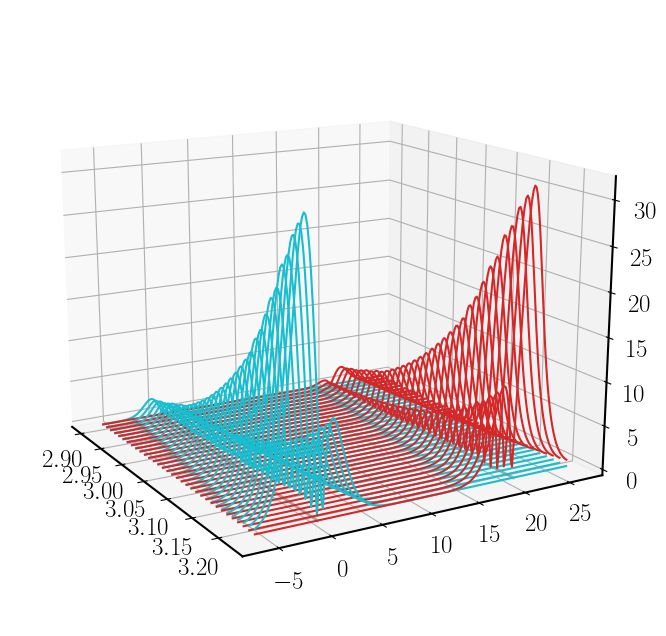

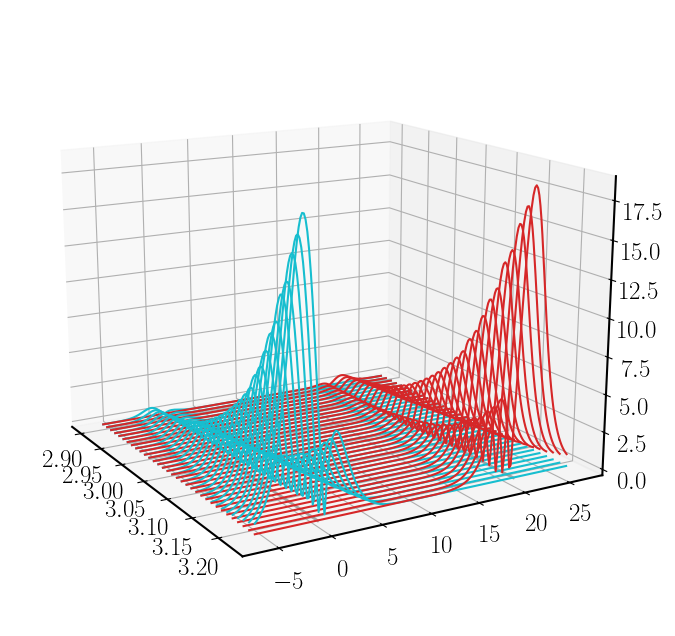

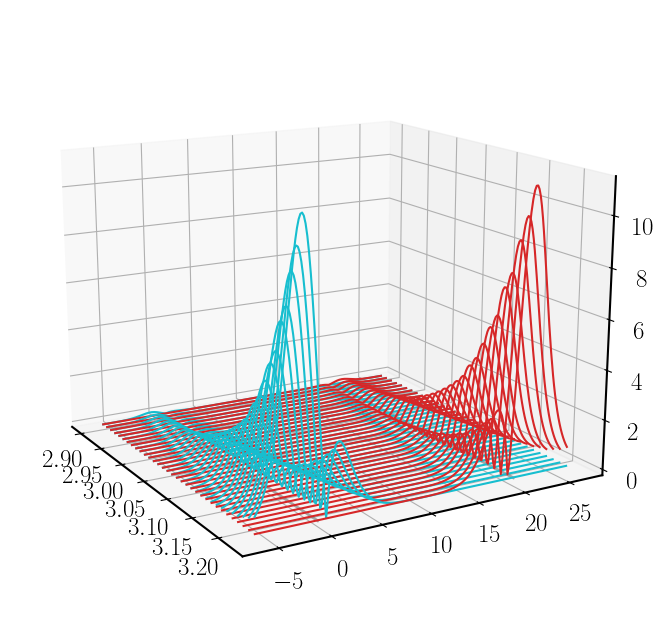

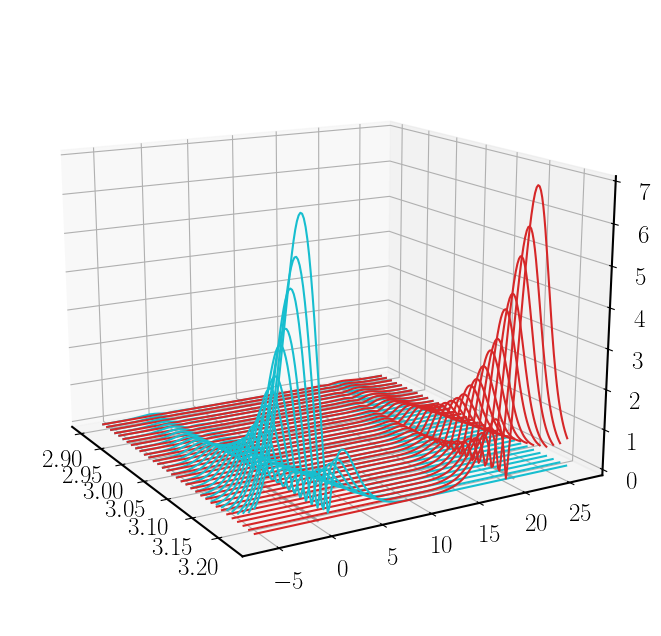

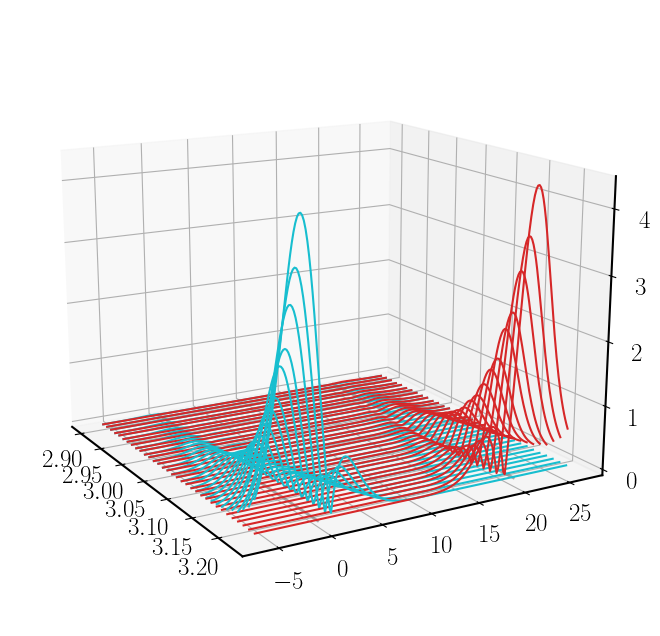

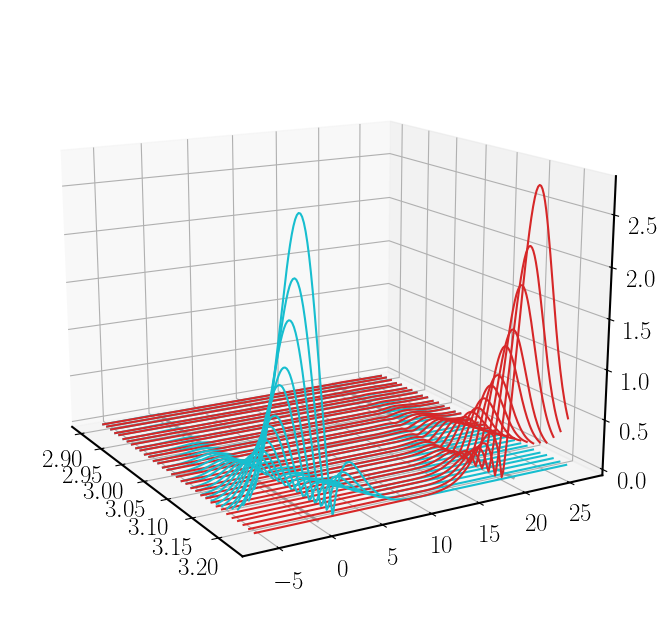

In [248]:
Num=34
sites = np.linspace(0,204,205)
xa = (sites*(3*Num/2 + 30)/204 - 15)*0.4
mag = (np.sqrt(s/1444) * (mu0 * (2*mub)**2)/(2 * a**3 *h_planck)) * 1e-3
dlist = np.array([5, 6.25, 7.5, 8.75, 10,11.25,12.5, 13.75, 15],dtype=object)
omegalist = np.linspace(2.9,3.22,33,dtype=object)
   
for d in dlist:  
    left_edge = []
    right_edge = []
    total = []
    for omega in omegalist:
        nk = mag*np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin")
        if len(nk) != 410:
            print(f"File for d={d}, omega={omega} has length {len(nk)}, expected 410. Skipping.")
            continue
        if np.sum(nk[0:100]) > np.sum(nk[250:350]):
            left_edge.append(nk[:205])
            right_edge.append(nk[205:])
            total.append(nk[205:]-nk[:205])
        else:
            left_edge.append(nk[205:])
            right_edge.append(nk[:205])
            total.append(nk[:205]-nk[205:])

    left = 0
    right = 3*(Num)*0.4/2

    ax = plt.figure(figsize=(8,8)).add_subplot(projection='3d')
    ax.set_proj_type('persp',focal_length=0.5)
    plt.tick_params(labelsize=18,direction="in",length=10,width=1,color='black')
    plt.plot(omegalist, left, color='gray', linewidth=2, alpha=0.67, marker='')
    plt.plot(omegalist, right, color='gray', linewidth=2, alpha=0.67, marker='')
    # # Axes3D has no direct 2D fill_between; create a thin surface between left and right for each omega
    # X = np.column_stack((omegalist, omegalist))   # shape (M,2)
    # Y = np.column_stack((left, right))            # shape (M,2)
    # Z = np.zeros_like(Y)
    # ax.plot_surface(X, Y, Z, color='gray', alpha=0.33, linewidth=0, shade=True)
    ax.view_init(15, -30)

    for j in range(len(left_edge)):
        plt.plot(xa, left_edge[j], zs=omegalist[j], zdir='x', label=rf"$\omega/2\pi={omegalist[j]}$ (THz)",marker='',color='tab:cyan')
        plt.plot(xa, right_edge[j], zs=omegalist[j], zdir='x', label=rf"$\omega/2\pi={omegalist[j]}$ (THz)",marker='',color='tab:red')


## Spatial Profiles

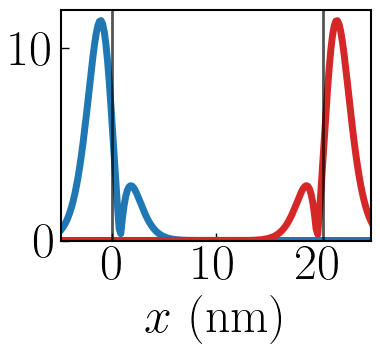

In [52]:
d=10
omega = 3.17
# ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin"))
# ns = natsorted(glob.glob(rf"C:\Users\jeffc\TopoMagnon\SQ_MANR_g_d=12.5_bin\MANR-SQ_g_d=15_omega=*.bin"))
left_edge = []
right_edge = []
# cmap = plt.get_cmap("rainbow").resampled(len(ns[20:80][::2]))
plt.figure(figsize=(4,3))
x = np.linspace(min(xa), max(xa), 1000)
nk = mag*np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin", dtype=np.float64)
# nk_int_left = scipy.interpolate.interp1d(xa, nk[:101], kind='cubic')
# nk_int_right = scipy.interpolate.interp1d(xa, nk[101:], kind='cubic')
# plt.plot(x,nk_int_left(x),color='tab:blue',marker='',markersize=4,linewidth=5)
# plt.plot(x,nk_int_right(x),color='tab:red',marker='',markersize=4,linewidth=5)
# plt.scatter(-0.48550608001683315, nk[16], color='black', s=100, marker='x')

if np.sum(nk[0:100]) > np.sum(nk[250:350]):
    left_edge.append(nk[:205])
    right_edge.append(nk[205:])
    total.append(nk[205:]-nk[:205])
else:
    left_edge.append(nk[205:])
    right_edge.append(nk[:205])
    total.append(nk[:205]-nk[205:])
plt.plot(xa, left_edge[0], color='tab:blue', marker='', markersize=4, linewidth=5)
plt.plot(xa, right_edge[0], color='tab:red', marker='', markersize=4, linewidth=5)
plt.xlabel(r"$x$ (nm)",fontsize=36)
plt.ylabel(r"",fontsize=36)
plt.ylim(0,)
# plt.yscale("log")
plt.xlim(-5,25)
# plt.yticks([0,250,500,750], fontsize=42)
plt.xticks([0,10,20], fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=6,width=1,color='black')
plt.axvline(x=0, color='black', linewidth=2, linestyle='-', alpha=0.67)
plt.axvline(x=(3*Num)*0.4/2, color='black', linewidth=2, linestyle='-', alpha=0.67)

# maxg_right = max(nk_int_right(x))
# maxg_idx = np.where(nk_int_right(x) == maxg_right)[0][0]
# maxg_x = x[maxg_idx]
# plt.scatter(maxg_x, maxg_right, color='gray', s=150, marker='*', zorder=5)


# plt.savefig(f"figures/d={d}_MANR_edge_modes.svg", dpi=300, bbox_inches='tight')

## Scaling

Text(0.5, 0, '$|k_x|a$')

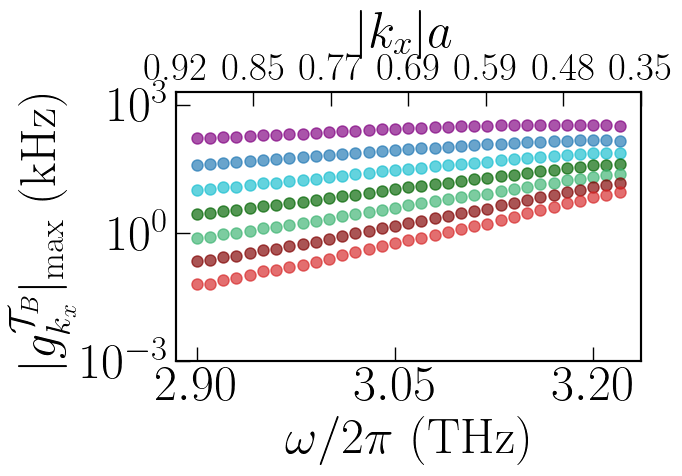

In [ ]:
dlist = np.array([5, 6.25, 7.5, 8.75, 10, 11.25, 12.5],dtype=object)
omegalist = np.linspace(2.9,3.22,33,dtype=object)
ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\MZNR_kx_list.bin", dtype=np.float64)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
colors = ['purple','tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']


plt.figure(figsize=(6,3.5))
for d in dlist:  
    left_edge = []
    right_edge = []
    total = []
    for omega in omegalist:
        nk = mag*np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin")
        if len(nk) != 410:
            print(f"File for d={d}, omega={omega} has length {len(nk)}, expected 410. Skipping.")
            continue
        if np.sum(nk[0:100]) > np.sum(nk[250:350]):
            left_edge.append(nk[:205])
            right_edge.append(nk[205:])
            total.append(nk[205:]-nk[:205])
        else:
            left_edge.append(nk[205:])
            right_edge.append(nk[:205])
            total.append(nk[:205]-nk[205:])


    maxg = np.max(left_edge,axis=1)
    plt.plot(omegalist, maxg, label=rf"$d={d}a$",marker='o',markersize=8,linewidth=3,alpha=0.67,linestyle='',color=colors[np.where(dlist==d)[0][0]])
    plt.xticks([2.9,3.05,3.2], fontsize=24)
    # popt, pcov = scipy.optimize.curve_fit(fit_func, omega[:50], maxg[:50],maxfev = 8000, bounds=([0, -np.inf, -np.inf], [np.inf, 0, np.inf]))
    # plt.plot(omega, fit_func(omega, *popt), linestyle='-',color=colors[np.where(dlist==d)[0][0]], alpha=0.67)
plt.ylabel(r"$|g_{k_x}^{\mathcal{T}_B}|_{\max}$ (kHz)",fontsize=36)
plt.xlabel(r"$\omega/2\pi$ (THz)",fontsize=36)
plt.yscale("log")
# plt.xscale("log")
# plt.axvline(x=2.74,color='black', linestyle='-', alpha=0.67,linewidth=3)
# plt.axvline(x=3.08,color='black', linestyle='-', alpha=0.67,linewidth=3)
# plt.axvline(x=3,color='gray', linestyle='--', alpha=0.67,linewidth=3)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
# plt.xlim(2.75)
plt.ylim(1e-3,2*1e3)
# plt.legend(frameon=False, fontsize=36, ncols=3, bbox_to_anchor=(1.05, 1))

ax2 = plt.twiny()
plt.tick_params(labelsize=28,direction="in",length=10,width=1,color='black')
ax2.set_xticks(np.linspace(0,1,len(ks[::5])),np.round(ks[::5],2))
ax2.set_xlabel(r"$|k_x|a$", fontsize=36)

# plt.savefig("figures/omega_vs_maxg_V2.svg", dpi=300, bbox_inches='tight')

### with $|k_x|a$

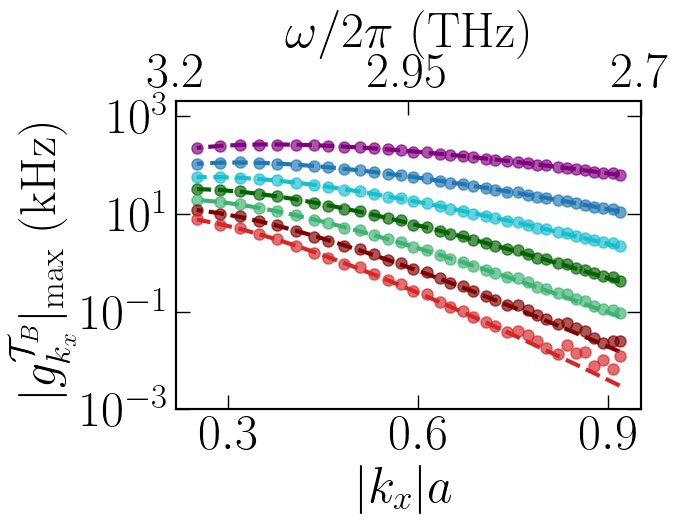

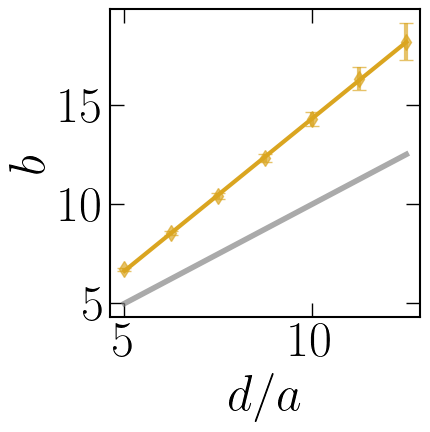

In [41]:
dlist = np.array([5, 6.25, 7.5, 8.75, 10, 11.25, 12.5],dtype=object)
omegalist = np.linspace(2.7,3.23,34,dtype=object)
ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\MZNR_kx_list.bin", dtype=np.float64)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
colors = ['purple','tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']

b = []
b_err = []
c = []
c_err = []

def fit_func(x,a,b,c):
    return a*(x**c)*np.exp(-b*x)

plt.figure(figsize=(6,4))
for d in dlist:  
    left_edge = []
    right_edge = []
    total = []
    for omega in omegalist:
        nk = mag*np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin")
        if len(nk) != 410:
            print(f"File for d={d}, omega={omega} has length {len(nk)}, expected 410. Skipping.")
            continue
        if np.sum(nk[0:100]) > np.sum(nk[250:350]):
            left_edge.append(nk[:205])
            right_edge.append(nk[205:])
            total.append(nk[205:]-nk[:205])
        else:
            left_edge.append(nk[205:])
            right_edge.append(nk[:205])
            total.append(nk[:205]-nk[205:])


    maxg = np.max(left_edge,axis=1)
    plt.plot(ks, maxg, label=rf"$d={d}a$",marker='o',markersize=8,linewidth=3,alpha=0.67,linestyle='',color=colors[np.where(dlist==d)[0][0]])
    # plt.xticks([2.9,3.05,3.2], fontsize=24)
    popt, pcov = scipy.optimize.curve_fit(fit_func, ks, maxg, maxfev = 8000, bounds=([0, 0, -np.inf], [np.inf, np.inf, 4]))
    b.append(popt[1])
    b_err.append(np.sqrt(pcov[1,1]))
    c.append(popt[2])
    c_err.append(np.sqrt(pcov[2,2]))

    plt.plot(ks, fit_func(ks, *popt), linestyle='--',color=colors[np.where(dlist==d)[0][0]], alpha=1, linewidth=3)
plt.ylabel(r"$|g_{k_x}^{\mathcal{T}_B}|_{\max}$ (kHz)",fontsize=36)
plt.xlabel(r"$|k_x|a$",fontsize=36)
plt.yscale("log")
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black',right=True)
plt.ylim(1e-3,2*1e3)
plt.xticks([0.3,0.6,0.9])
# plt.legend(frameon=False, fontsize=36, ncols=3, bbox_to_anchor=(1.05, 1))

ax2 = plt.twiny()
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')
ax2.set_xticks([0,0.5,1],[3.2,2.95,2.7])
ax2.set_xlabel(r"$\omega/2\pi$ (THz)", fontsize=36)

# plt.savefig("figures/omega_vs_maxg_V2.svg", dpi=300, bbox_inches='tight')



plt.figure(figsize=(4,4))
plt.errorbar(dlist, b, yerr=np.abs(b_err), marker='d', linestyle='',linewidth=3, markersize=8, alpha = 0.67 ,color='goldenrod', capsize=5)
popt,pcov = scipy.optimize.curve_fit(linfit, dlist, b, maxfev = 8000)
plt.plot(dlist, linfit(dlist,*popt), linewidth=3, color='goldenrod')
plt.plot(dlist,dlist, marker='', linestyle='-', color='gray', linewidth=4, alpha=0.67)
plt.ylabel(r"$b$",fontsize=36)
plt.xlabel(r"$d/a$",fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black', top=True, right=True)



# plt.figure(figsize=(4,4))
# plt.errorbar(dlist, c, yerr=np.abs(c_err), marker='o', linestyle='',linewidth=3, color='black', capsize=5)
# plt.ylabel(r"$c/a$",fontsize=36)
# plt.xlabel(r"$d/a$",fontsize=36)
# plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black')

## $x_{\max}$

(-2.0, 0.0)

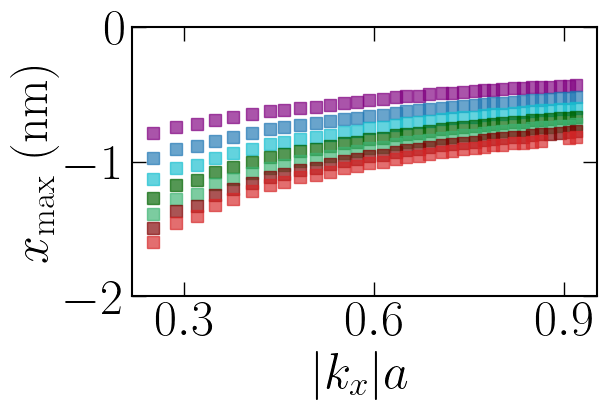

In [58]:
dlist = np.array([5, 6.25, 7.5, 8.75, 10, 11.25, 12.5],dtype=object)
omegalist = np.linspace(2.7,3.23,34,dtype=object)
ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\MZNR_kx_list.bin", dtype=np.float64)
# colors = ['purple','tab:pink','tab:blue','tab:cyan','darkgreen','mediumseagreen', 'lightgreen','maroon','tab:red']
colors = ['purple','tab:blue','tab:cyan','darkgreen', 'mediumseagreen','maroon','tab:red']

x = np.linspace(-2, 2, 10000)

plt.figure(figsize=(6,3.5))

for d in dlist:  
    maxposition = []
    for omega in omegalist:
        nk = mag*np.fromfile(rf"C:\Users\jeffc\TopoMagnon\SQ_MZNR_g_V2\MZNR-SQ_g_d={d}_omega={omega:.2f}.bin")
        if len(nk) != 410:
            print(f"File for d={d}, omega={omega} has length {len(nk)}, expected 410. Skipping.")
            continue
        elif np.sum(nk[0:51]) > np.sum(nk[150:201]):
            nk_int_left = scipy.interpolate.interp1d(xa[:100], nk[:205][:100], kind='cubic')
        else:
            nk_int_left = scipy.interpolate.interp1d(xa[:100], nk[205:][:100], kind='cubic')
        max_pos = np.where(nk_int_left(x) == np.max(nk_int_left(x)))[0][0]
        maxposition.append(x[max_pos])
    plt.plot(ks, np.array(maxposition), marker='s', linestyle='',markersize=8, linewidth=2, alpha=0.67, color=colors[np.where(dlist==d)[0][0]], label=rf"$\omega/2\pi={omega}$ (THz)")

plt.ylabel(r"$x_{\max}$ (nm)",fontsize=36)
plt.xlabel(r"$|k_x|a$",fontsize=36)
plt.xticks([0.3,0.6,0.9], fontsize=36)
plt.tick_params(labelsize=36,direction="in",length=10,width=1,color='black', top=True, right=True)
# plt.xlim(2.9,3.2)
plt.ylim(-2,0)
# plt.yscale("log")
# plt.legend(frameon=False, fontsize=14, ncols=2)

# ks = np.fromfile(rf"C:\Users\jeffc\TopoMagnon\klist_all.bin", dtype=np.float64)
# ax2 = plt.twiny()
# plt.tick_params(labelsize=32,direction="in",length=10,width=1,color='black')
# ax2.set_xticks(np.linspace(0,1,len(ks[::20])),np.round(ks[::20],2))
# ax2.set_xlabel(r"$|k_y|a$", fontsize=36)

# plt.savefig("figures/xmax_v_omega.svg", dpi=300, bbox_inches='tight')